In [1]:
import xarray as xr 
import xesmf as xe
member ='1091.005'
import numpy as np
data_dir = "/Data/gfi/share/ModData/CESM2_LENS2/atmos/daily/historical/"

In [2]:
from dask.distributed import Client,LocalCluster


cluster=  LocalCluster(n_workers=6, memory_limit='20GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 6
Total threads: 66,Total memory: 120.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38275,Workers: 6
Dashboard: http://127.0.0.1:8787/status,Total threads: 66
Started: Just now,Total memory: 120.00 GiB
Comm: tcp://127.0.0.1:44283,Total threads: 11
Dashboard: http://127.0.0.1:38883/status,Memory: 20.00 GiB
Nanny: tcp://127.0.0.1:43619,


In [37]:
ds_z = xr.open_mfdataset(f'{data_dir}/Z/HIST_Z500_1091.005_*.nc', chunks=dict(time=365*5)).Z500*10
ds_u = xr.open_mfdataset(f'{data_dir}/U850/HIST_U850_{member}_*.nc', chunks=dict(time=365*5)).U850
ds_v = xr.open_mfdataset(f'{data_dir}/V850/HIST_V850_{member}_*.nc', chunks=dict(time=365*5)).V850
ds_cesm = xr.concat([ds_z.assign_coords(var_name='z500'),
                ds_u.assign_coords(var_name='u850'),
                ds_v.assign_coords(var_name='v850'),
                ], dim='var_name').sel(time=slice('1979','2015'))

/tmp/ipykernel_2401521/3404643300.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1825. This could degrade performance. Instead, consider rechunking after loading.
  ds_z = xr.open_mfdataset(f'{data_dir}/Z/HIST_Z500_1091.005_*.nc', chunks=dict(time=365*5)).Z500*10
/tmp/ipykernel_2401521/3404643300.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1825. This could degrade performance. Instead, consider rechunking after loading.
  ds_z = xr.open_mfdataset(f'{data_dir}/Z/HIST_Z500_1091.005_*.nc', chunks=dict(time=365*5)).Z500*10
/tmp/ipykernel_2401521/3404643300.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1825. This could degrade performance. Instead, consider rechunking after loading.
  ds_z = xr.open_mfdataset(f'{data_dir}/Z/HIST_Z500_1091.005_*.nc', chunks=dict(time=365*5)).Z500*10
/tmp/ipykernel_2401521/34

In [38]:
ds_era = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_NH_32x128.nc').sel(var_name=['z500','u850','v850']).sel(time=slice('1979','2015'))
ds_era

<xarray.Dataset> Size: 664MB
Dimensions:      (latitude: 32, longitude: 128, var_name: 3, time: 13514)
Coordinates:
  * latitude     (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
  * longitude    (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * var_name     (var_name) <U4 48B 'z500' 'u850' 'v850'
  * time         (time) datetime64[ns] 108kB 1979-01-01 ... 2015-12-31
Data variables:
    data_normed  (time, var_name, latitude, longitude) float32 664MB ...
    mean_value   (var_name, latitude, longitude) float32 49kB ...
    std_value    (var_name) float32 12B ...

In [39]:
regridder = xe.Regridder(ds_cesm, ds_era.data_normed, 'bilinear',periodic=True)
ds_cesm2_regridded = regridder(ds_cesm, output_chunks = dict(lon=30, lat=30))

In [40]:
ds_cesm2_regridded_normed = (ds_cesm2_regridded - ds_era.mean_value)/ds_era.std_value
# bias_mean_cesm2 = ds_cesm2_regridded_normed.mean('time').load()
# ds_cesm2_regridded_normed = ds_cesm2_regridded_normed - bias_mean_cesm2

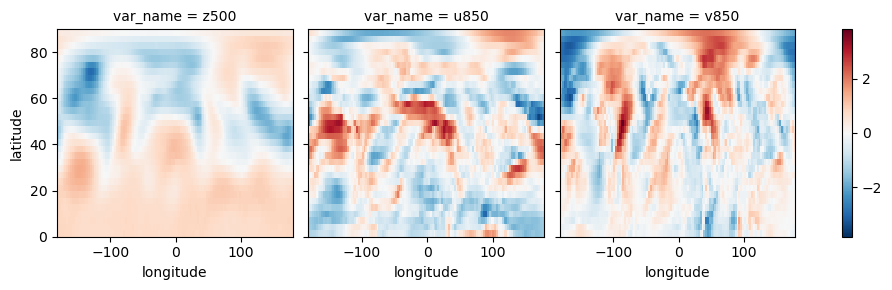

In [ ]:
ds_cesm2_regridded_normed.isel(time=0).plot(col='var_name')

In [43]:
ds_cesm2_regridded_normed.to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_NH_32x128_CESM2.nc')

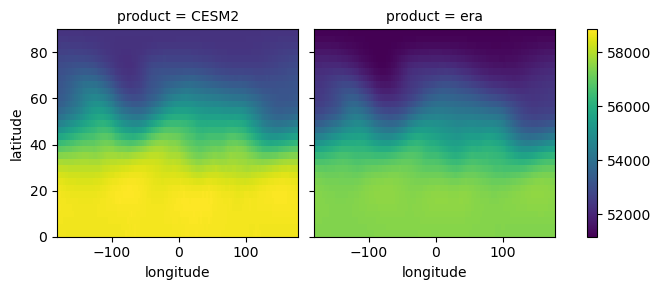

In [36]:
xr.concat([ds_cesm2_regridded.mean('time').assign_coords(product='CESM2')*10, ds_era.mean_value.assign_coords(product='era')], dim='product').sel(var_name='z500').plot(col='product')

In [49]:
ds_rain = xr.open_dataarray('/felles_gfi/felles_gfi_users/rogui7909/era5_rain_norge/ERA5land_daily_TP_indices.nc')

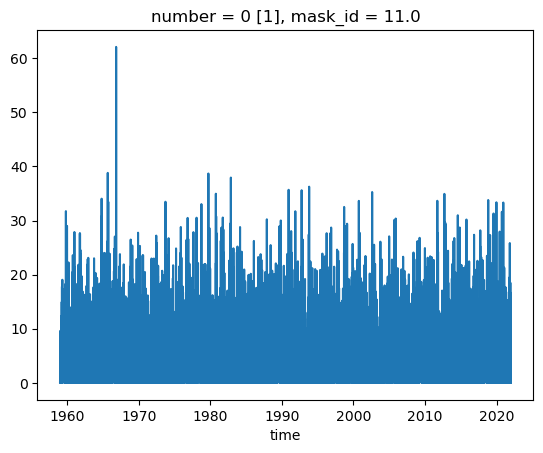

In [53]:
ds_rain.sel(mask_id=11).plot()

In [3]:
ds_rain_cesm2 = xr.open_mfdataset(f'/Data/gfi/share/ModData/CESM2_LENS2/atmos/6hourly/historical/PRECT/HIST_PRECT_{member}_*', chunks = dict(lon=50, lat=50, time=4*365*10)).PRECT
ds_rain_cesm2_daily = ds_rain_cesm2.resample(time='D').mean().rename(lon='longitude',lat='latitude')
ds_rain_cesm2_daily = ds_rain_cesm2_daily.assign_coords(longitude = ds_rain_cesm2_daily.longitude.where(ds_rain_cesm2_daily.longitude<180,ds_rain_cesm2_daily.longitude-360 ))
ds_rain_cesm2_daily = ds_rain_cesm2_daily.sortby('longitude')


/tmp/ipykernel_2424206/328736038.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds_rain_cesm2 = xr.open_mfdataset(f'/Data/gfi/share/ModData/CESM2_LENS2/atmos/6hourly/historical/PRECT/HIST_PRECT_{member}_*', chunks = dict(lon=50, lat=50, time=4*365*10)).PRECT
/tmp/ipykernel_2424206/328736038.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds_rain_cesm2 = xr.open_mfdataset(f'/Data/gfi/share/ModData/CESM2_LENS2/atmos/6hourly/historical/PRECT/HIST_PRECT_{member}_*', chunks = dict(lon=50, lat=50, time=4*365*10)).PRECT
/tmp/ipykernel_2424206/328736038.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 50. This could degrade performance. Instead, consider rech

In [4]:
mask=xr.open_dataarray('/Data/gfi/users/jodor4442/rainfall_regions/K39_ERA5land_lat_weighted_2d_direct.nc').load()


In [6]:
mask_cesm2 = mask.interp_like(ds_rain_cesm2_daily, method='nearest')
mask_cesm2 = mask_cesm2.dropna('longitude', how='all').dropna('latitude', how='all')
weights = np.cos(np.deg2rad(mask_cesm2-mask_cesm2+mask_cesm2.latitude))
weights_per_mask = weights.groupby(mask_cesm2).sum()


In [8]:

m_s_to_mm_day = 86_400_000
rain_per_region  =(ds_rain_cesm2_daily*weights).groupby(mask_cesm2).sum()/weights_per_mask*m_s_to_mm_day

In [9]:
rain_per_region.to_netcdf('/Data/gfi/users/rogui7909/data/ERA5/CESM2_1member_rain_indices.nc')